# Airline Passenger Satisfaction — Bivariate Analysis

This notebook visualizes the relationship between overall satisfaction and the variables required for the three predefined hypotheses. It is intentionally descriptive: **no hypothesis tests, p-values, confidence intervals, regression models, or statistical-significance conclusions are included**.

The plots address:

1. Service ratings and satisfaction
2. Travel class and satisfaction
3. Flight delays and satisfaction

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", context="notebook")
COLORS = sns.color_palette("colorblind")
SATISFACTION_COLORS = {"Satisfied": COLORS[2], "Neutral or Dissatisfied": COLORS[1]}
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data/processed/airline_passenger_satisfaction_cleaned.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} passenger records and {df.shape[1]} columns.")

Loaded 129,880 passenger records and 70 columns.


## 1. Scope and analysis conventions

- `is_satisfied = 1` represents **Satisfied**; `0` represents **Neutral or Dissatisfied**.
- Clean service-rating fields treat undocumented zero ratings as missing.
- Counts and denominators are displayed so percentage differences can be interpreted in context.
- Delay outliers are retained. Distribution plots use a 99th-percentile viewing limit only for readability.
- Observed differences are descriptive associations and are not evidence of causation or statistical significance.

In [2]:
def outcome_summary(group_column, order=None):
    result = (
        df.groupby(group_column, dropna=False, observed=True)
        .agg(Passengers=("passenger_id", "size"), Satisfied=("is_satisfied", "sum"), Satisfaction_rate=("is_satisfied", "mean"))
        .reset_index()
    )
    result["Neutral_or_dissatisfied"] = result["Passengers"] - result["Satisfied"]
    if order is not None:
        result[group_column] = pd.Categorical(result[group_column], categories=order, ordered=True)
        result = result.sort_values(group_column).reset_index(drop=True)
    return result

def display_outcome_table(table):
    display(table.style.format({
        "Passengers": "{:,}", "Satisfied": "{:,}",
        "Neutral_or_dissatisfied": "{:,}", "Satisfaction_rate": "{:.1%}"
    }).hide(axis="index"))

def annotate_rates(ax):
    for patch in ax.patches:
        height = patch.get_height()
        if np.isfinite(height):
            ax.text(patch.get_x() + patch.get_width()/2, height, f"{height:.1%}", ha="center", va="bottom", fontsize=9)

## 2. Hypothesis 1 variables: service quality and satisfaction

The first hypothesis concerns cleanliness, seat comfort, and onboard service. The following charts show how the observed satisfaction rate and satisfaction composition vary across each clean rating level.

In [3]:
service_variables = {
    "cleanliness_rating_clean": "Cleanliness",
    "seat_comfort_rating_clean": "Seat comfort",
    "onboard_service_rating_clean": "Onboard service",
}
service_tables = {}
for column, label in service_variables.items():
    table = outcome_summary(column, order=[1, 2, 3, 4, 5]).rename(columns={column: "Rating"})
    service_tables[label] = table
    display(Markdown(f"**{label} rating and satisfaction**"))
    display_outcome_table(table)

**Cleanliness rating and satisfaction**

Rating,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
1,"16,729","3,295",19.7%,"13,434"
2,"20,113","4,277",21.3%,"15,836"
3,"30,639","13,269",43.3%,"17,370"
4,"33,969","18,183",53.5%,"15,786"
5,"28,416","17,404",61.2%,"11,012"
nan,14,0,0.0%,14


**Seat comfort rating and satisfaction**

Rating,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
1,"15,108","3,374",22.3%,"11,734"
2,"18,529","4,188",22.6%,"14,341"
3,"23,328","4,994",21.4%,"18,334"
4,"39,756","22,275",56.0%,"17,481"
5,"33,158","21,597",65.1%,"11,561"
nan,1,0,0.0%,1


**Onboard service rating and satisfaction**

Rating,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
1,"14,787","2,908",19.7%,"11,879"
2,"18,351","4,688",25.5%,"13,663"
3,"28,542","9,079",31.8%,"19,463"
4,"38,703","20,690",53.5%,"18,013"
5,"29,492","19,063",64.6%,"10,429"
nan,5,0,0.0%,5


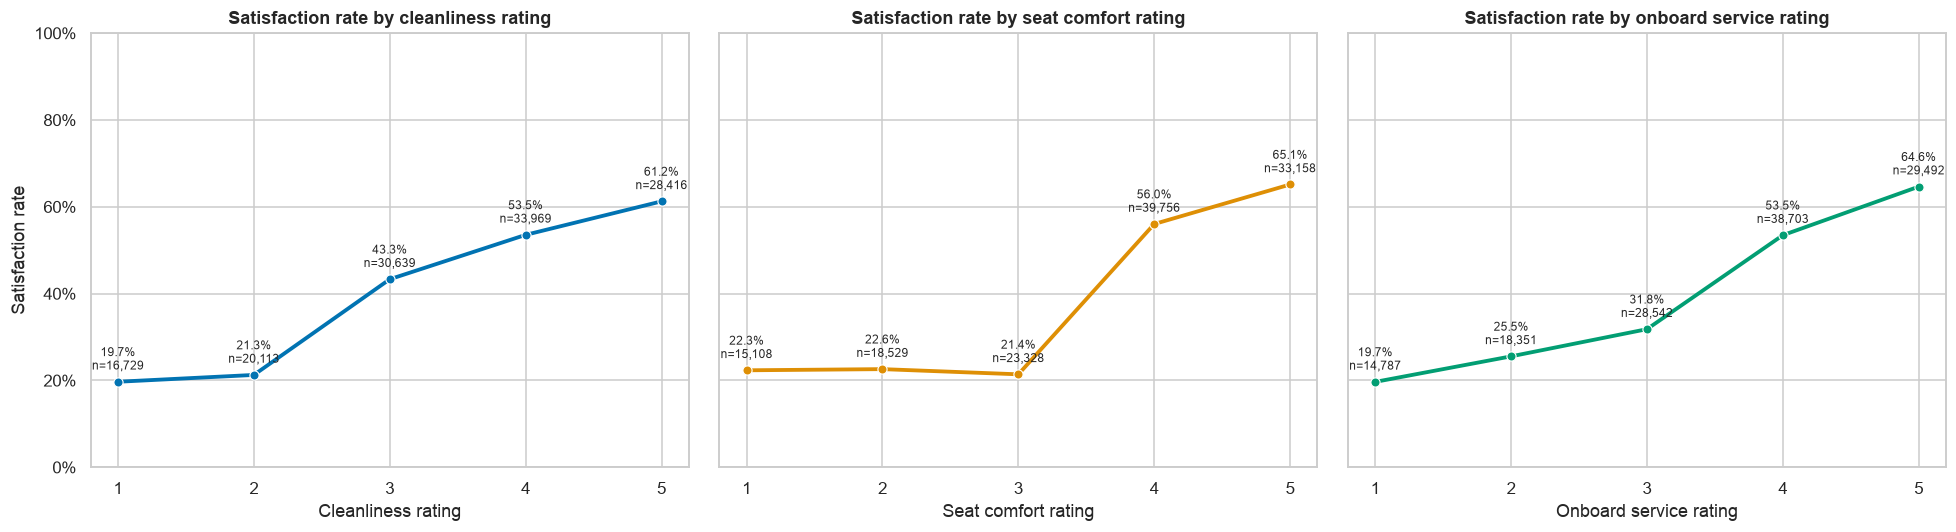

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (label, table), color in zip(axes, service_tables.items(), COLORS):
    sns.lineplot(data=table, x="Rating", y="Satisfaction_rate", marker="o", linewidth=2.5, color=color, ax=ax)
    ax.set(title=f"Satisfaction rate by {label.lower()} rating", xlabel=f"{label} rating", ylabel="Satisfaction rate", ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks([1, 2, 3, 4, 5])
    for x, y, n in zip(table["Rating"], table["Satisfaction_rate"], table["Passengers"]):
        ax.annotate(f"{y:.1%}\nn={n:,}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

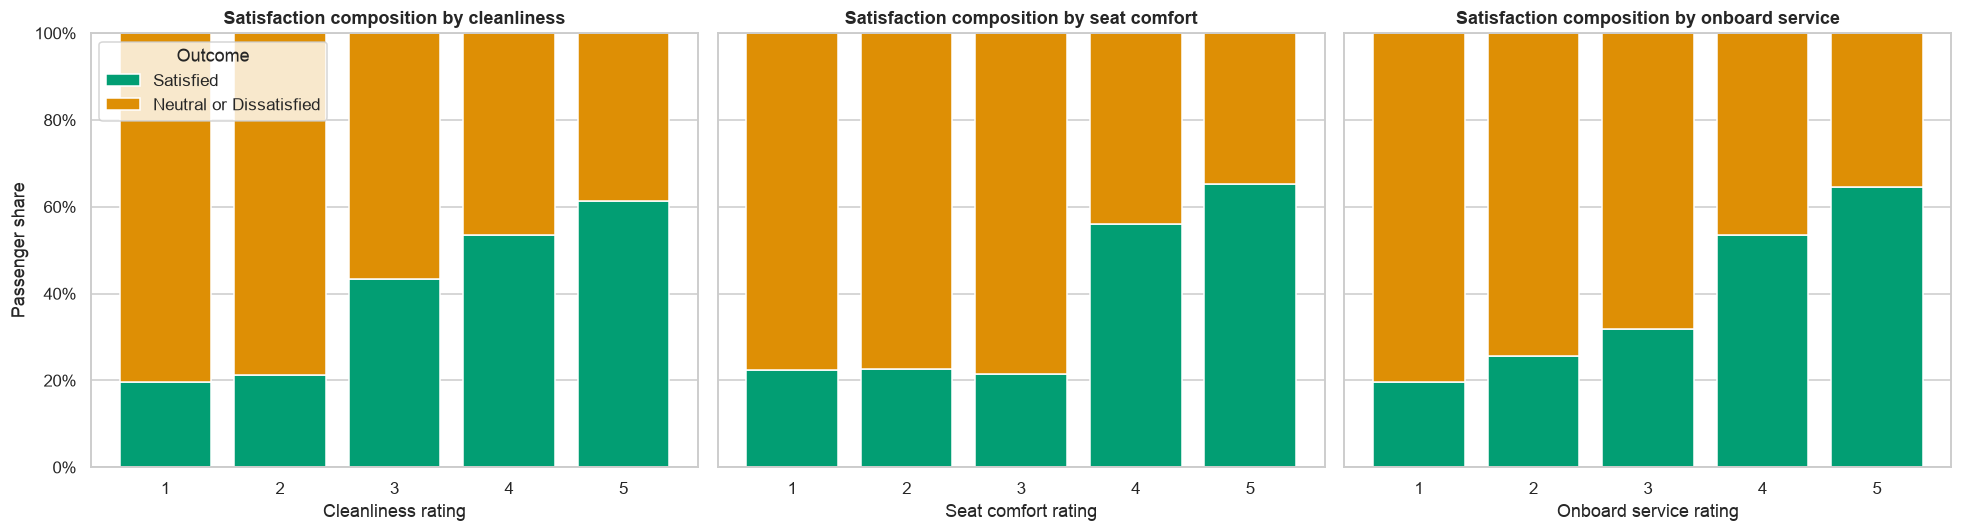

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (column, label) in zip(axes, service_variables.items()):
    composition = pd.crosstab(df[column], df["satisfaction"], normalize="index").reindex(index=[1, 2, 3, 4, 5])
    composition = composition.reindex(columns=["Satisfied", "Neutral or Dissatisfied"])
    composition.plot(kind="bar", stacked=True, color=[SATISFACTION_COLORS[c] for c in composition.columns], ax=ax, width=.8)
    ax.set(title=f"Satisfaction composition by {label.lower()}", xlabel=f"{label} rating", ylabel="Passenger share", ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=0)
    if ax is not axes[0]: ax.get_legend().remove()
axes[0].legend(title="Outcome", loc="upper left")
plt.tight_layout()
plt.show()

,Passengers,Mean,Median,Std. dev.,Minimum,Maximum
satisfaction,,,,,,
Neutral or Dissatisfied,"73,452",3.00,3.00,0.93,1.00,5.00
Satisfied,"56,428",3.86,4.00,0.77,1.00,5.00


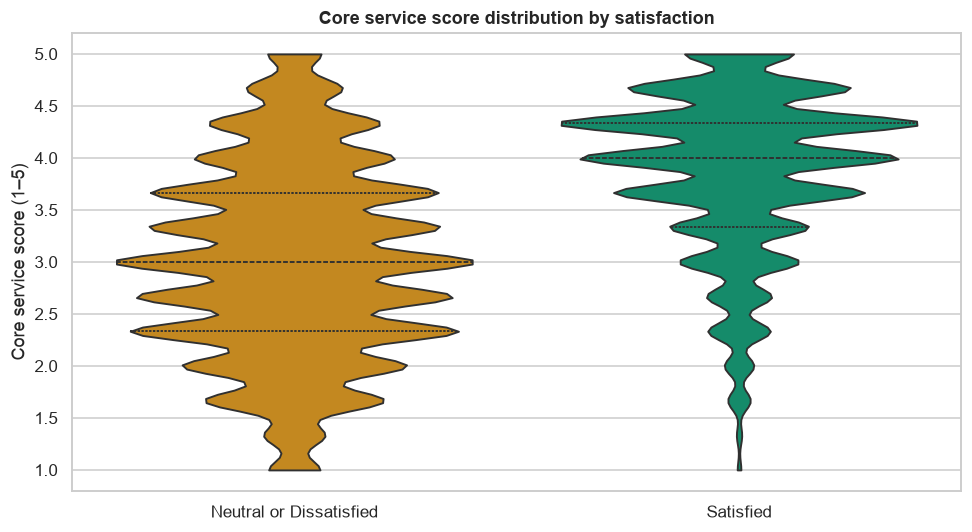

In [6]:
core_summary = (
    df.groupby("satisfaction")["core_service_score_clean"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .rename(columns={"count": "Passengers", "mean": "Mean", "median": "Median", "std": "Std. dev.", "min": "Minimum", "max": "Maximum"})
)
display(core_summary.style.format({"Passengers": "{:,}", "Mean": "{:.2f}", "Median": "{:.2f}", "Std. dev.": "{:.2f}", "Minimum": "{:.2f}", "Maximum": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=df, x="satisfaction", y="core_service_score_clean", hue="satisfaction", palette=SATISFACTION_COLORS, legend=False, inner="quartile", cut=0, ax=ax)
ax.set(title="Core service score distribution by satisfaction", xlabel="", ylabel="Core service score (1–5)")
plt.tight_layout()
plt.show()

**Descriptive reading only:** These plots show the observed pattern and group sizes. They do not determine whether the association is statistically significant, independent of other variables, or causal.

## 3. Hypothesis 2 variables: travel class and satisfaction

The next views compare the satisfaction outcome across Business, Economy Plus, and Economy passengers.

In [7]:
class_order = ["Business", "Economy Plus", "Economy"]
class_summary = outcome_summary("travel_class", order=class_order)
display_outcome_table(class_summary)

travel_class,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
Business,"62,160","43,166",69.4%,"18,994"
Economy Plus,"9,411","2,319",24.6%,"7,092"
Economy,"58,309","10,943",18.8%,"47,366"


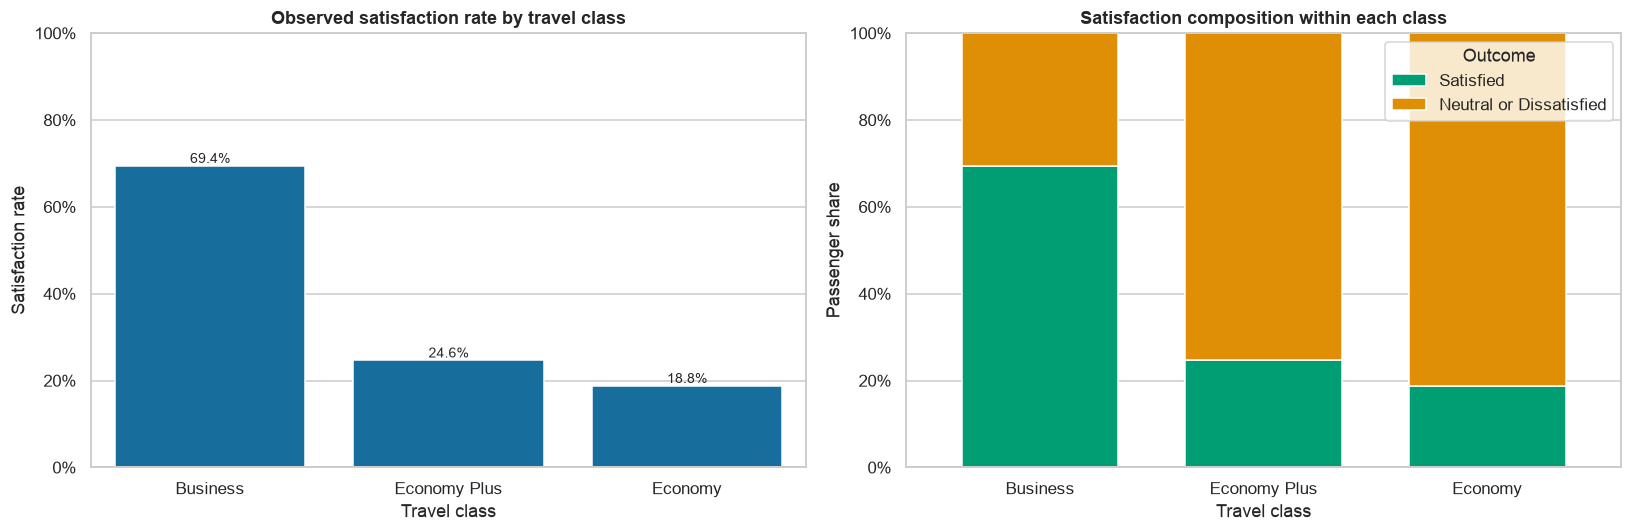

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=class_summary, x="travel_class", y="Satisfaction_rate", color=COLORS[0], ax=axes[0])
axes[0].set(title="Observed satisfaction rate by travel class", xlabel="Travel class", ylabel="Satisfaction rate", ylim=(0, 1))
axes[0].yaxis.set_major_formatter(PercentFormatter(1))
annotate_rates(axes[0])

class_composition = pd.crosstab(df["travel_class"], df["satisfaction"], normalize="index").reindex(class_order)
class_composition = class_composition.reindex(columns=["Satisfied", "Neutral or Dissatisfied"])
class_composition.plot(kind="bar", stacked=True, color=[SATISFACTION_COLORS[c] for c in class_composition.columns], ax=axes[1], width=.7)
axes[1].set(title="Satisfaction composition within each class", xlabel="Travel class", ylabel="Passenger share", ylim=(0, 1))
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Outcome")
plt.tight_layout()
plt.show()

**Descriptive reading only:** Class groups differ in size and may also differ in travel purpose, distance, customer type, and service experience. This section does not adjust for those factors or test the observed differences.

## 4. Hypothesis 3 variables: delays and satisfaction

Departure and arrival delay are viewed both as continuous distributions and as predefined descriptive bands. The 393 records with missing arrival delay remain visible as a separate band.

In [9]:
delay_by_outcome = (
    df.groupby("satisfaction")[["departure_delay", "arrival_delay"]]
    .agg(["count", "mean", "median", "max"])
)
display(delay_by_outcome.style.format("{:.1f}"))

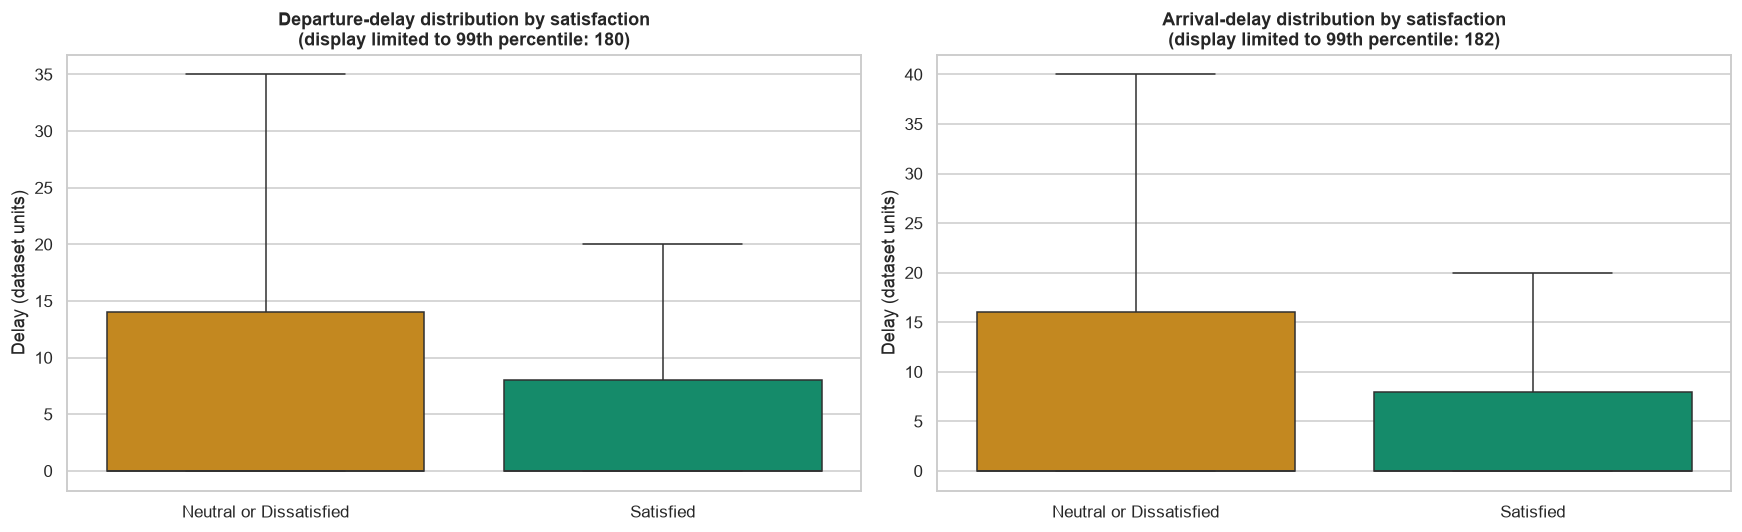

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, column, title in [
    (axes[0], "departure_delay", "Departure-delay distribution by satisfaction"),
    (axes[1], "arrival_delay", "Arrival-delay distribution by satisfaction"),
]:
    viewing_limit = df[column].quantile(.99)
    plot_data = df.loc[df[column].le(viewing_limit), [column, "satisfaction"]]
    sns.boxplot(data=plot_data, x="satisfaction", y=column, hue="satisfaction", palette=SATISFACTION_COLORS, legend=False, showfliers=False, ax=ax)
    ax.set(title=f"{title}\n(display limited to 99th percentile: {viewing_limit:.0f})", xlabel="", ylabel="Delay (dataset units)")
plt.tight_layout()
plt.show()

In [11]:
departure_order = ["No delay", "Short (1-15)", "Moderate (16-60)", "Long (>60)"]
arrival_order = departure_order + ["Missing"]
departure_band_summary = outcome_summary("departure_delay_band", departure_order)
arrival_band_summary = outcome_summary("arrival_delay_band", arrival_order)
display(Markdown("**Departure-delay bands**"))
display_outcome_table(departure_band_summary)
display(Markdown("**Arrival-delay bands**"))
display_outcome_table(arrival_band_summary)

**Departure-delay bands**

departure_delay_band,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
No delay,"73,356","33,699",45.9%,"39,657"
Short (1-15),"27,787","12,100",43.5%,"15,687"
Moderate (16-60),"19,762","7,411",37.5%,"12,351"
Long (>60),"8,975","3,218",35.9%,"5,757"


**Arrival-delay bands**

arrival_delay_band,Passengers,Satisfied,Satisfaction_rate,Neutral_or_dissatisfied
No delay,"72,753","34,490",47.4%,"38,263"
Short (1-15),"27,176","11,194",41.2%,"15,982"
Moderate (16-60),"20,470","7,345",35.9%,"13,125"
Long (>60),"9,088","3,233",35.6%,"5,855"
Missing,393,166,42.2%,227


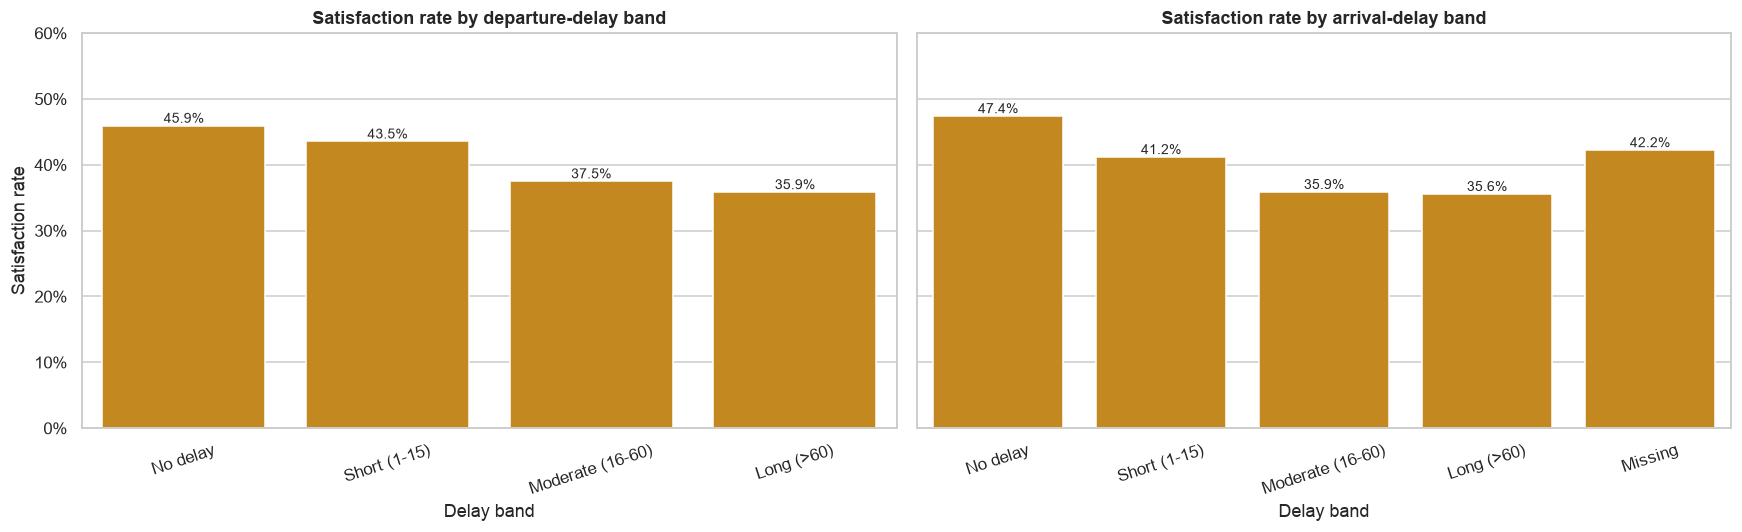

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, table, category, title in [
    (axes[0], departure_band_summary, "departure_delay_band", "Satisfaction rate by departure-delay band"),
    (axes[1], arrival_band_summary, "arrival_delay_band", "Satisfaction rate by arrival-delay band"),
]:
    sns.barplot(data=table, x=category, y="Satisfaction_rate", color=COLORS[1], ax=ax)
    ax.set(title=title, xlabel="Delay band", ylabel="Satisfaction rate", ylim=(0, .6))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=18)
    annotate_rates(ax)
plt.tight_layout()
plt.show()

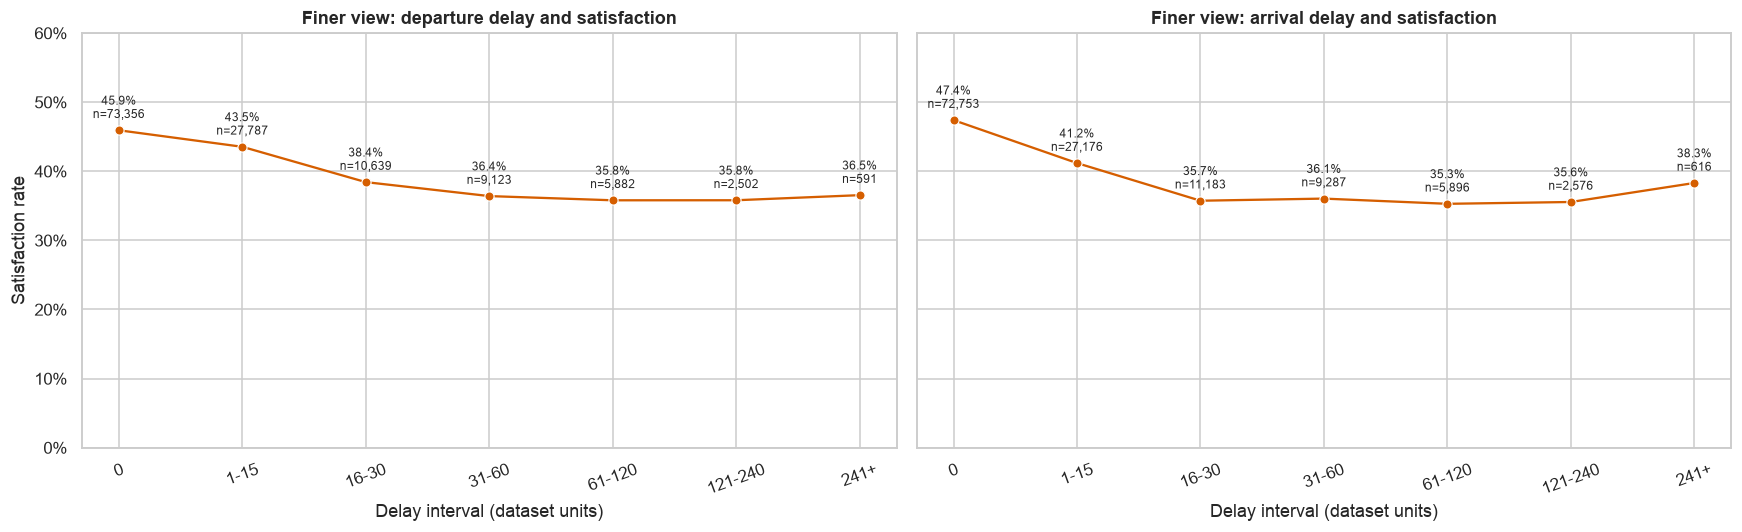

In [13]:
fine_edges = [-1, 0, 15, 30, 60, 120, 240, np.inf]
fine_labels = ["0", "1-15", "16-30", "31-60", "61-120", "121-240", "241+"]
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, column, title in [
    (axes[0], "departure_delay", "Finer view: departure delay and satisfaction"),
    (axes[1], "arrival_delay", "Finer view: arrival delay and satisfaction"),
]:
    temporary_band = pd.cut(df[column], bins=fine_edges, labels=fine_labels)
    table = (df.assign(delay_interval=temporary_band).groupby("delay_interval", observed=True).agg(Passengers=("passenger_id", "size"), Satisfaction_rate=("is_satisfied", "mean")).reset_index())
    sns.lineplot(data=table, x="delay_interval", y="Satisfaction_rate", marker="o", color=COLORS[3], ax=ax)
    ax.set(title=title, xlabel="Delay interval (dataset units)", ylabel="Satisfaction rate", ylim=(0, .6))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=20)
    for x, row in enumerate(table.itertuples()):
        ax.annotate(f"{row.Satisfaction_rate:.1%}\nn={row.Passengers:,}", (x, row.Satisfaction_rate), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

**Descriptive reading only:** Delay intervals are analyst-defined summaries. The visual pattern does not establish a statistically significant or causal effect, and no missing-delay imputation has been performed.

## 5. Retention proxy across satisfaction and experience levels

**Definition and limitation:** `customer_type = Returning` is used as a retention proxy. The dataset does not track the same customer over time, so the figures below show the **share of surveyed passengers labeled Returning**, not a true cohort-retention rate.

This section descriptively compares the proxy across satisfaction outcomes and within service-rating, travel-class, and delay groups. No statistical tests or causal conclusions are included.

satisfaction,Passengers,Returning_customers,Returning_share
Neutral or Dissatisfied,"73,452","55,372",75.4%
Satisfied,"56,428","50,728",89.9%


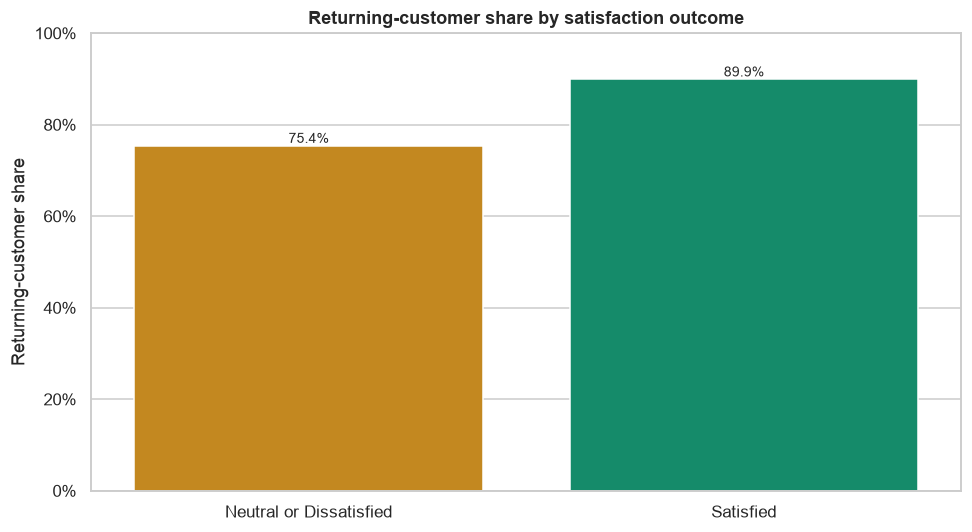

In [14]:
retention_data = df.assign(is_returning=df["customer_type"].eq("Returning").astype(int))

retention_by_satisfaction = (
    retention_data.groupby("satisfaction", observed=True)
    .agg(Passengers=("passenger_id", "size"), Returning_customers=("is_returning", "sum"), Returning_share=("is_returning", "mean"))
    .reset_index()
)
display(retention_by_satisfaction.style.hide(axis="index").format({
    "Passengers": "{:,}", "Returning_customers": "{:,}", "Returning_share": "{:.1%}"
}))

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=retention_by_satisfaction, x="satisfaction", y="Returning_share", hue="satisfaction", palette=SATISFACTION_COLORS, legend=False, ax=ax)
ax.set(title="Returning-customer share by satisfaction outcome", xlabel="", ylabel="Returning-customer share", ylim=(0, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
annotate_rates(ax)
plt.tight_layout()
plt.show()

### 5.1 Service ratings, satisfaction, and the retention proxy

Each line represents one satisfaction outcome. The vertical axis is the share of passengers labeled Returning within each rating-and-satisfaction subgroup. Clean ratings exclude undocumented zero values.

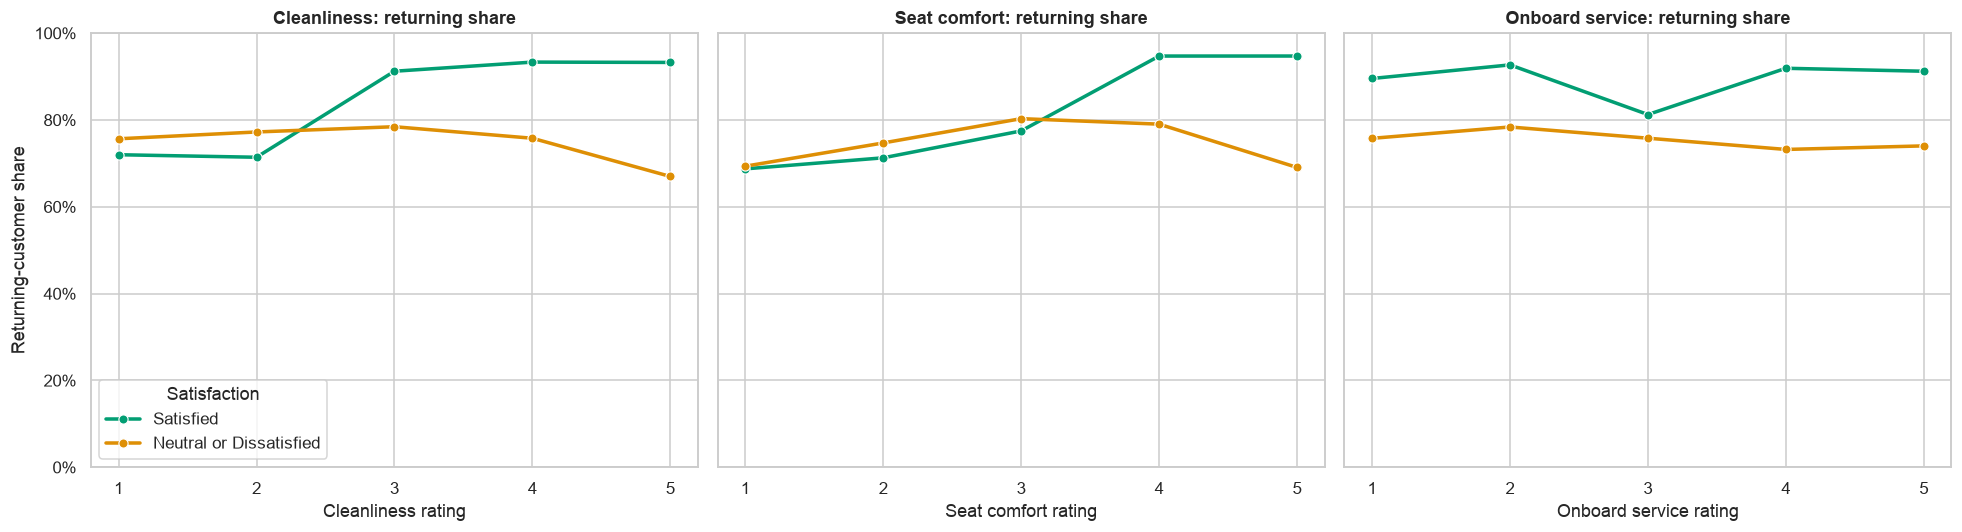

Service,Rating,satisfaction,Passengers,Returning_customers,Returning_share
Cleanliness,1,Neutral or Dissatisfied,"13,434","10,164",75.7%
Cleanliness,1,Satisfied,"3,295","2,372",72.0%
Cleanliness,2,Neutral or Dissatisfied,"15,836","12,230",77.2%
Cleanliness,2,Satisfied,"4,277","3,054",71.4%
Cleanliness,3,Neutral or Dissatisfied,"17,370","13,625",78.4%
Cleanliness,3,Satisfied,"13,269","12,104",91.2%
Cleanliness,4,Neutral or Dissatisfied,"15,786","11,963",75.8%
Cleanliness,4,Satisfied,"18,183","16,969",93.3%
Cleanliness,5,Neutral or Dissatisfied,"11,012","7,376",67.0%
Cleanliness,5,Satisfied,"17,404","16,229",93.2%


In [15]:
service_retention_tables = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (column, label) in zip(axes, service_variables.items()):
    table = (
        retention_data.dropna(subset=[column])
        .groupby([column, "satisfaction"], observed=True)
        .agg(Passengers=("passenger_id", "size"), Returning_customers=("is_returning", "sum"), Returning_share=("is_returning", "mean"))
        .reset_index()
        .rename(columns={column: "Rating"})
    )
    service_retention_tables[label] = table
    sns.lineplot(data=table, x="Rating", y="Returning_share", hue="satisfaction", hue_order=["Satisfied", "Neutral or Dissatisfied"], palette=SATISFACTION_COLORS, marker="o", linewidth=2.3, ax=ax)
    ax.set(title=f"{label}: returning share", xlabel=f"{label} rating", ylabel="Returning-customer share", ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xticks([1, 2, 3, 4, 5])
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Satisfaction")
plt.tight_layout()
plt.show()

service_retention_table = pd.concat(
    [table.assign(Service=label) for label, table in service_retention_tables.items()],
    ignore_index=True,
)[["Service", "Rating", "satisfaction", "Passengers", "Returning_customers", "Returning_share"]]
display(service_retention_table.style.hide(axis="index").format({
    "Rating": "{:.0f}", "Passengers": "{:,}", "Returning_customers": "{:,}", "Returning_share": "{:.1%}"
}))

### 5.2 Travel class, satisfaction, and the retention proxy

The grouped bars compare returning-customer share between the two satisfaction outcomes within each travel class.

travel_class,satisfaction,Passengers,Returning_customers,Returning_share
Business,Neutral or Dissatisfied,"18,994","13,425",70.7%
Business,Satisfied,"43,166","39,504",91.5%
Economy Plus,Neutral or Dissatisfied,"7,092","6,250",88.1%
Economy Plus,Satisfied,"2,319","2,246",96.9%
Economy,Neutral or Dissatisfied,"47,366","35,697",75.4%
Economy,Satisfied,"10,943","8,978",82.0%


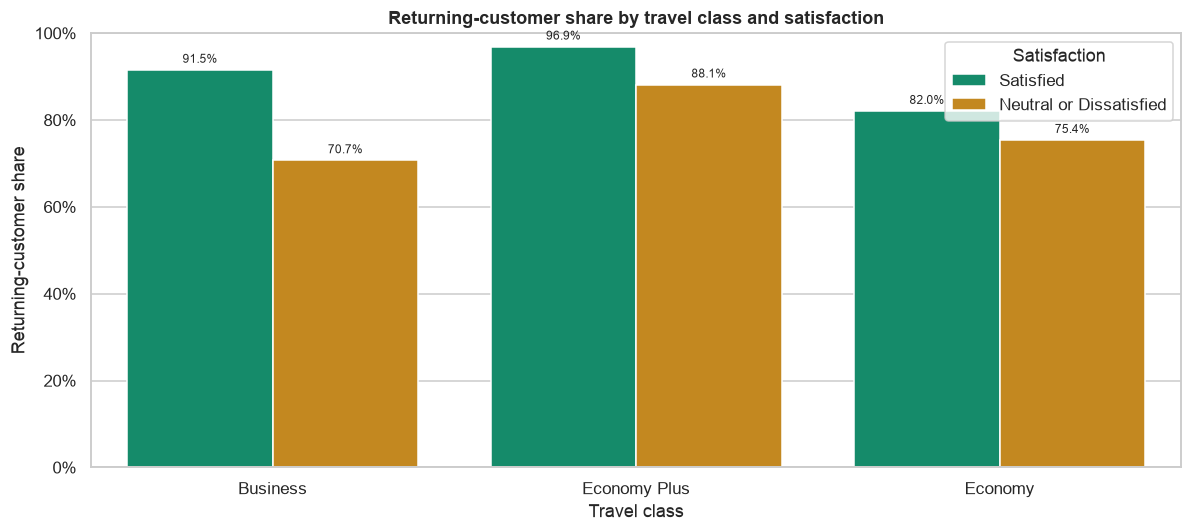

In [16]:
class_retention = (
    retention_data.groupby(["travel_class", "satisfaction"], observed=True)
    .agg(Passengers=("passenger_id", "size"), Returning_customers=("is_returning", "sum"), Returning_share=("is_returning", "mean"))
    .reset_index()
)
class_retention["travel_class"] = pd.Categorical(class_retention["travel_class"], categories=class_order, ordered=True)
class_retention = class_retention.sort_values(["travel_class", "satisfaction"])
display(class_retention.style.hide(axis="index").format({
    "Passengers": "{:,}", "Returning_customers": "{:,}", "Returning_share": "{:.1%}"
}))

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=class_retention, x="travel_class", y="Returning_share", hue="satisfaction", hue_order=["Satisfied", "Neutral or Dissatisfied"], palette=SATISFACTION_COLORS, ax=ax)
ax.set(title="Returning-customer share by travel class and satisfaction", xlabel="Travel class", ylabel="Returning-customer share", ylim=(0, 1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
for container in ax.containers:
    ax.bar_label(container, labels=[f"{bar.get_height():.1%}" for bar in container], padding=3, fontsize=8)
ax.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

### 5.3 Flight delays, satisfaction, and the retention proxy

The delay-band views retain every record. Missing arrival delay remains a separate category rather than being imputed.

**Departure-delay bands**

departure_delay_band,satisfaction,Passengers,Returning_customers,Returning_share
No delay,Neutral or Dissatisfied,"39,657","29,681",74.8%
No delay,Satisfied,"33,699","30,302",89.9%
Short (1-15),Neutral or Dissatisfied,"15,687","11,891",75.8%
Short (1-15),Satisfied,"12,100","10,874",89.9%
Moderate (16-60),Neutral or Dissatisfied,"12,351","9,436",76.4%
Moderate (16-60),Satisfied,"7,411","6,666",89.9%
Long (>60),Neutral or Dissatisfied,"5,757","4,364",75.8%
Long (>60),Satisfied,"3,218","2,886",89.7%


**Arrival-delay bands**

arrival_delay_band,satisfaction,Passengers,Returning_customers,Returning_share
No delay,Neutral or Dissatisfied,"38,263","28,574",74.7%
No delay,Satisfied,"34,490","30,970",89.8%
Short (1-15),Neutral or Dissatisfied,"15,982","12,166",76.1%
Short (1-15),Satisfied,"11,194","10,087",90.1%
Moderate (16-60),Neutral or Dissatisfied,"13,125","10,009",76.3%
Moderate (16-60),Satisfied,"7,345","6,624",90.2%
Long (>60),Neutral or Dissatisfied,"5,855","4,450",76.0%
Long (>60),Satisfied,"3,233","2,893",89.5%
Missing,Neutral or Dissatisfied,227,173,76.2%
Missing,Satisfied,166,154,92.8%


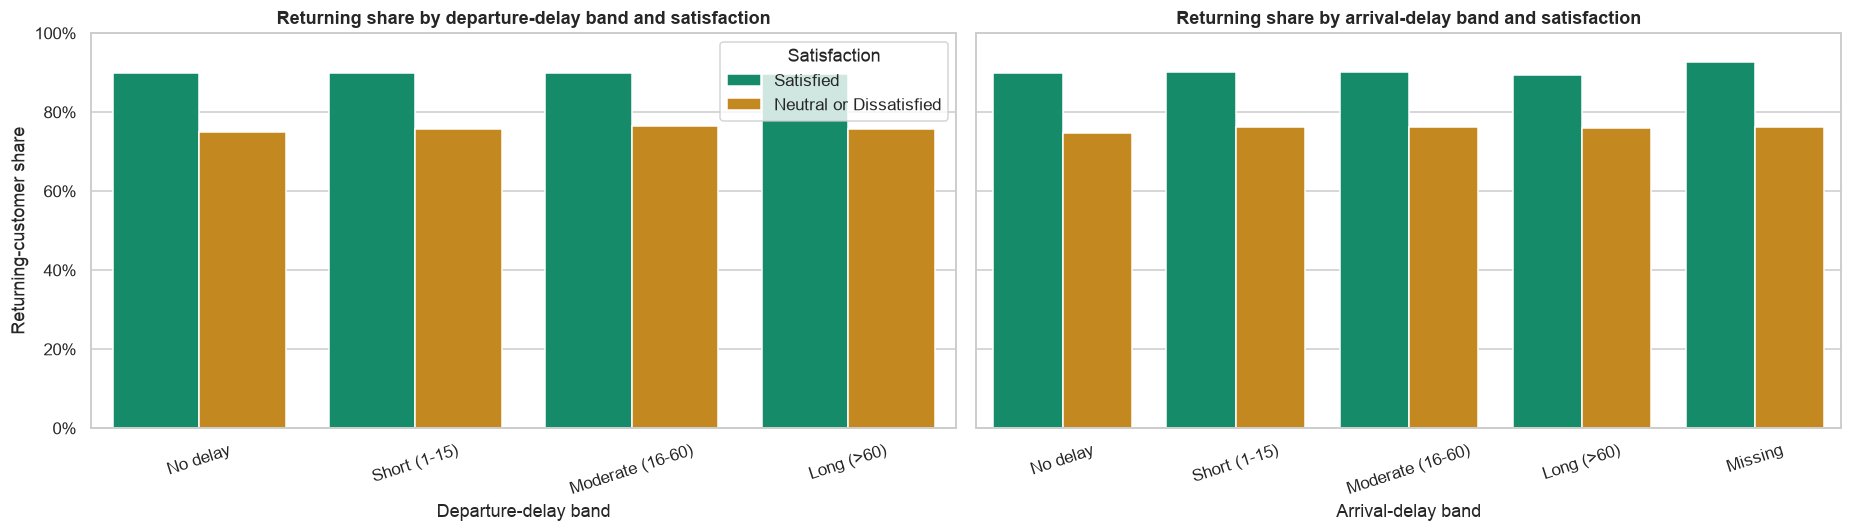

In [17]:
def retention_by_delay_band(column, order):
    table = (
        retention_data.groupby([column, "satisfaction"], observed=True)
        .agg(Passengers=("passenger_id", "size"), Returning_customers=("is_returning", "sum"), Returning_share=("is_returning", "mean"))
        .reset_index()
    )
    table[column] = pd.Categorical(table[column], categories=order, ordered=True)
    return table.sort_values([column, "satisfaction"]).reset_index(drop=True)

departure_retention = retention_by_delay_band("departure_delay_band", departure_order)
arrival_retention = retention_by_delay_band("arrival_delay_band", arrival_order)

display(Markdown("**Departure-delay bands**"))
display(departure_retention.style.hide(axis="index").format({
    "Passengers": "{:,}", "Returning_customers": "{:,}", "Returning_share": "{:.1%}"
}))
display(Markdown("**Arrival-delay bands**"))
display(arrival_retention.style.hide(axis="index").format({
    "Passengers": "{:,}", "Returning_customers": "{:,}", "Returning_share": "{:.1%}"
}))

fig, axes = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for ax, table, category, title in [
    (axes[0], departure_retention, "departure_delay_band", "Departure-delay band"),
    (axes[1], arrival_retention, "arrival_delay_band", "Arrival-delay band"),
]:
    sns.barplot(data=table, x=category, y="Returning_share", hue="satisfaction", hue_order=["Satisfied", "Neutral or Dissatisfied"], palette=SATISFACTION_COLORS, ax=ax)
    ax.set(title=f"Returning share by {title.lower()} and satisfaction", xlabel=title, ylabel="Returning-customer share", ylim=(0, 1))
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.tick_params(axis="x", rotation=18)
    if ax is not axes[0]:
        ax.get_legend().remove()
axes[0].legend(title="Satisfaction")
plt.tight_layout()
plt.show()

In [18]:
overall_proxy = retention_by_satisfaction.set_index("satisfaction")["Returning_share"]
cleanliness_proxy = service_retention_tables["Cleanliness"].pivot(index="Rating", columns="satisfaction", values="Returning_share")
seat_proxy = service_retention_tables["Seat comfort"].pivot(index="Rating", columns="satisfaction", values="Returning_share")
onboard_proxy = service_retention_tables["Onboard service"].pivot(index="Rating", columns="satisfaction", values="Returning_share")
display(Markdown(f"""
**Descriptive interpretation**

- Returning-customer share is **{overall_proxy['Satisfied']:.1%}** among satisfied passengers and **{overall_proxy['Neutral or Dissatisfied']:.1%}** among neutral or dissatisfied passengers.
- For **cleanliness**, satisfied passengers have especially high returning shares at ratings 3–5 ({cleanliness_proxy.loc[3, 'Satisfied']:.1%} to {cleanliness_proxy.loc[5, 'Satisfied']:.1%}). At ratings 1–2, their returning share is slightly below the neutral-or-dissatisfied group.
- For **seat comfort**, the largest separation appears at ratings 4–5: returning share is about {seat_proxy.loc[4, 'Satisfied']:.1%}–{seat_proxy.loc[5, 'Satisfied']:.1%} among satisfied passengers, compared with {seat_proxy.loc[4, 'Neutral or Dissatisfied']:.1%} and {seat_proxy.loc[5, 'Neutral or Dissatisfied']:.1%} among neutral or dissatisfied passengers.
- For **onboard service**, satisfied passengers have a higher returning share at every rating level; however, neither satisfaction group's pattern rises consistently with every rating step.
- The service-rating, class, and delay charts show customer-status composition across observed subgroups, not conversion from first-time to returning status.
- These patterns do not measure how many first-time passengers later returned and do not establish that satisfaction, service ratings, class, or delays caused retention.
"""))


**Descriptive interpretation**

- Returning-customer share is **89.9%** among satisfied passengers and **75.4%** among neutral or dissatisfied passengers.
- For **cleanliness**, satisfied passengers have especially high returning shares at ratings 3–5 (91.2% to 93.2%). At ratings 1–2, their returning share is slightly below the neutral-or-dissatisfied group.
- For **seat comfort**, the largest separation appears at ratings 4–5: returning share is about 94.7%–94.7% among satisfied passengers, compared with 79.0% and 69.1% among neutral or dissatisfied passengers.
- For **onboard service**, satisfied passengers have a higher returning share at every rating level; however, neither satisfaction group's pattern rises consistently with every rating step.
- The service-rating, class, and delay charts show customer-status composition across observed subgroups, not conversion from first-time to returning status.
- These patterns do not measure how many first-time passengers later returned and do not establish that satisfaction, service ratings, class, or delays caused retention.


## 6. Review guide before hypothesis testing

Use these visual checks to decide whether the proposed statistical methods should account for:

- Ordered service-rating levels and unequal counts at each level
- Unequal class sample sizes
- Strongly right-skewed delay distributions and extreme values
- Missing arrival delays
- Potential nonlinear delay patterns

No hypothesis has been accepted, rejected, or formally tested in this notebook.